## import

Focal pixelpitch: [3.10546875, 3.10546875]
The input gaussian light beam waist: 6240um
The init gaussian phase is random generated.
2103


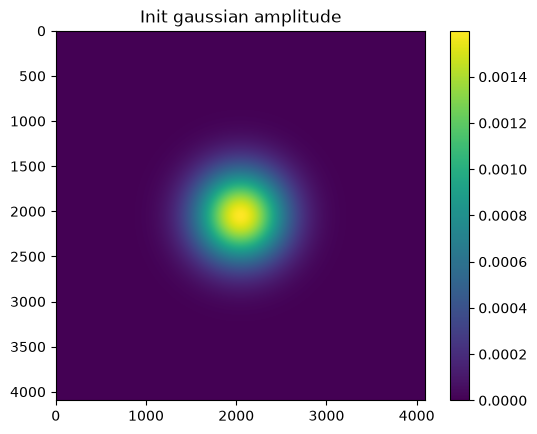

In [2]:


import WGS
import numpy as np
import scipy as sp
import torch
import torch.fft as fft
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from PIL import Image
import os
import time
import json
from Aberration import Zernike
from SLMGeneration import SLM_class
import json
import torch
from BlinkSLM import BlinkSLM
import avt
SLM = SLM_class()

SLM.image_init()

print(2103)

In [2]:
avt.get_image(200)

AttributeError: module 'avt' has no attribute 'get_image'

Focal pixelpitch: [3.10546875, 3.10546875]
The input gaussian light beam waist: 6240um
The init gaussian phase is random generated.


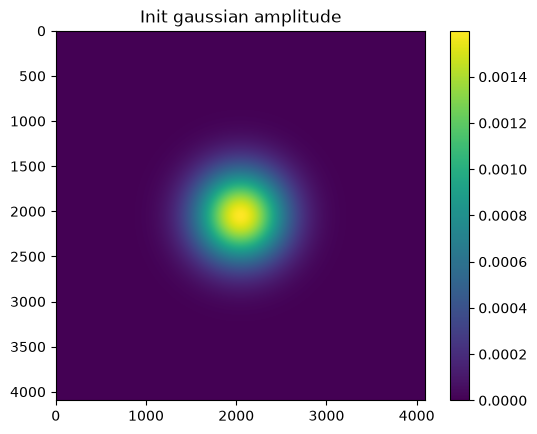

In [3]:
SLM.image_init(initGaussianPhase_user_defined = None, initGaussianPhase_save = False, Plot = True)
initSLMAmp=SLM.initGaussianAmp
# initSLMAmp=torch.from_numpy(initSLMAmp).float()  # 如果需要的话，可以改为 .double()
# initSLMPhase=np.random.rand(initSLMAmp.ImgResX, initSLMAmp.ImgResY)*2*np.pi-np.pi
plt.show()


focal pixelpitch: [3.10546875, 3.10546875]
array spacing: [150, 150]
spacing pixels: [48, 48]
arraysize: [8, 8]
(array([1880, 1880, 1880, 1880, 1880, 1880, 1880, 1880, 1928, 1928, 1928,
       1928, 1928, 1928, 1928, 1928, 1976, 1976, 1976, 1976, 1976, 1976,
       1976, 1976, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2072,
       2072, 2072, 2072, 2072, 2072, 2072, 2072, 2120, 2120, 2120, 2120,
       2120, 2120, 2120, 2120, 2168, 2168, 2168, 2168, 2168, 2168, 2168,
       2168, 2216, 2216, 2216, 2216, 2216, 2216, 2216, 2216]), array([1880, 1928, 1976, 2024, 2072, 2120, 2168, 2216, 1880, 1928, 1976,
       2024, 2072, 2120, 2168, 2216, 1880, 1928, 1976, 2024, 2072, 2120,
       2168, 2216, 1880, 1928, 1976, 2024, 2072, 2120, 2168, 2216, 1880,
       1928, 1976, 2024, 2072, 2120, 2168, 2216, 1880, 1928, 1976, 2024,
       2072, 2120, 2168, 2216, 1880, 1928, 1976, 2024, 2072, 2120, 2168,
       2216, 1880, 1928, 1976, 2024, 2072, 2120, 2168, 2216]))


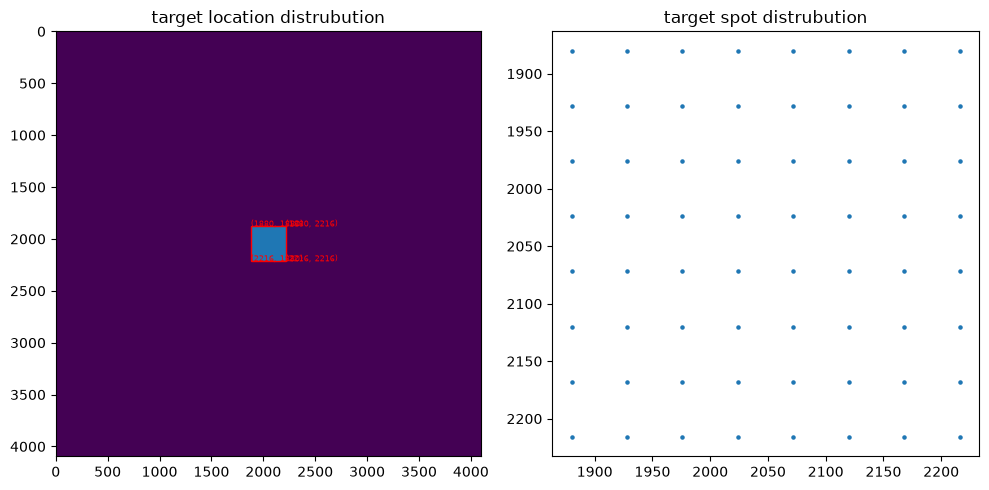

You have generated the target with [0, 0]um distance relative to the center.


In [4]:
Lattice_type="Rec"

gen_size = np.array([11,11])
array_size = np.flip(gen_size)
targetAmp=SLM.target_generate(Lattice_type,  Plot = True)

#targetAmp[np.nonzero(targetAmp)[0][0],np.nonzero(targetAmp)[1][0]] = 0
# gen_size = np.array([15,13])
# array_size = np.flip(gen_size)
# targetAmp=SLM.target_generate(Lattice_type, distance=(20, -6*7.5), arraysize=gen_size,  Plot = True)

# gen_size = np.array([8,10])
# array_size = np.flip(gen_size)
# targetAmp=SLM.target_generate(Lattice_type, distance=(20+7*7.5, 0), arraysize=gen_size,  Plot = True)
# test modify targetAmp
# print(targetAmp[1544, 1238])
# targetAmp[1793, 1623]=0
# targetAmp[2303, 1776]=0

# targetAmp_array=np.nonzero(targetAmp)
# print(f"targetAmp:{targetAmp}, nozero{targetAmp_array}")
# print(targetAmp[targetAmp_array])

# # first_row=targetAmp_array[0][0]
# # first_col=targetAmp_array[1][0]
# # targetAmp[first_row,first_col]=0

# # targetAmp=torch.from_numpy(targetAmp).float()

# ## 1544, 1646
# tmp = targetAmp.copy()
# tmp[100:200, 400:500]=1
# print(np.nonzero(targetAmp), np.where(targetAmp))
# plt.figure()
# plt.imshow(tmp)
# print("test where:", np.nonzero([[1, 0, 0, 1], [0,0, 0,0],[0,1, 0, 0]]))

# # only valid for rec lattice.
# point = np.where(targetAmp)
# startRow = point[0][0]
# endRow = point[0][-1]
# startCol = point[1][0]
# endCol = point[1][-1]
# vertices = [[startRow,startCol], [startRow,endCol], [endRow,endCol], [endRow,startCol]]
# tmp = np.zeros_like(targetAmp)
# tmp[startRow:endRow, startCol:endCol]=1
# plt.figure()
# plt.imshow(tmp)


## init phase

C:\Users\37828\AppData\Local\Temp\ipykernel_31516\2815704555.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  SLM_Phase=WGS.WGS_phase_generate(torch.tensor(initSLMAmp), torch.tensor(RandomPhase), torch.from_numpy(targetAmp), Loop=20, threshold=0.005, Plot=True)


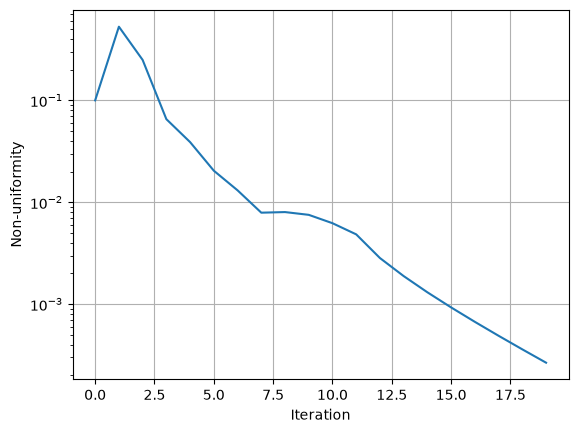

In [6]:
# 调用 WGS_phase_generate 函数
input_shape = (4096, 4096)  # 输入振幅分布的尺寸

RandomPhase = torch.rand(input_shape, dtype=torch.float32) * 2 * np.pi - np.pi

SLM_Phase=WGS.WGS_phase_generate(torch.tensor(initSLMAmp), torch.tensor(RandomPhase), torch.from_numpy(targetAmp), Loop=20, threshold=0.005, Plot=True)
SLM_screen=SLM.phase_to_screen(SLM_Phase.cpu().clone().numpy())


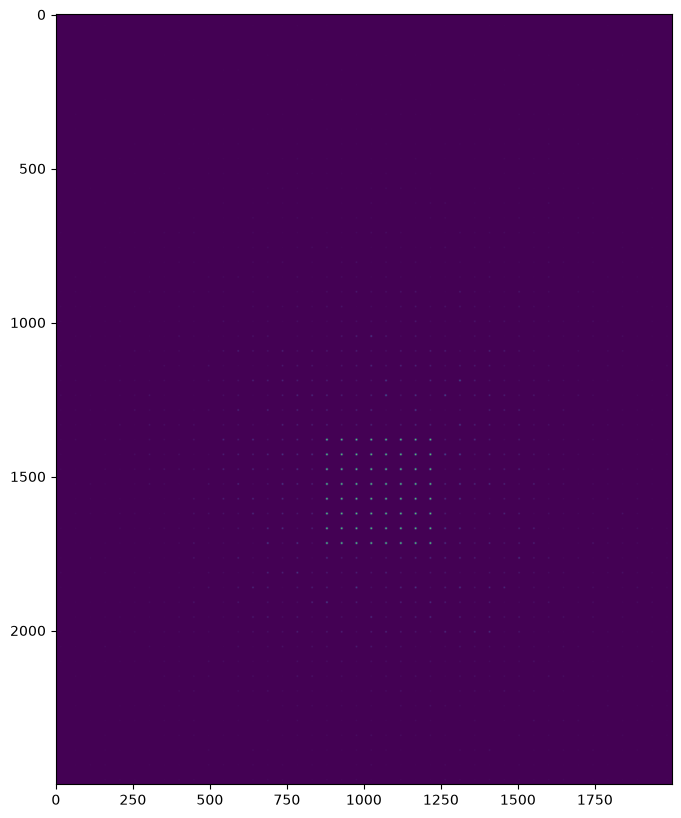

In [7]:

SLM_screen=SLM.phase_to_screen(SLM_Phase.cpu().clone().numpy())
fftAmp,fftPhase = SLM.phase_to_fftField(SLM_Phase.cpu())
plt.figure(figsize=(10,10))
plt.imshow(fftAmp[500:3000,1000:3000])
plt.show()
# blinkslm.slm_lib.Delete_SDK()

## write init phase to slm

In [8]:


import IMGpy
import slmpy

slm = slmpy.SLMdisplay(monitor=1,isImageLock = True)
tophat_screen_Corrected=IMGpy.SLM_screen_Correct(SLM_screen)


slm.updateArray(tophat_screen_Corrected)



In [ ]:
slm.updateArray(tophat_screen_Corrected)

slm.close()

In [ ]:
slm.close()

## 进行均匀性优化，读取IDS

In [9]:

import cv2
import numpy as np
import matplotlib
import copy
import matplotlib.pyplot as plt

# print(IDS_Camera.m_device.RemoteDevice().NodeMaps()[IDS_Camera.selected_device])


图像尺寸： (3036, 4024)
图像类型： uint8
最大灰度： 163


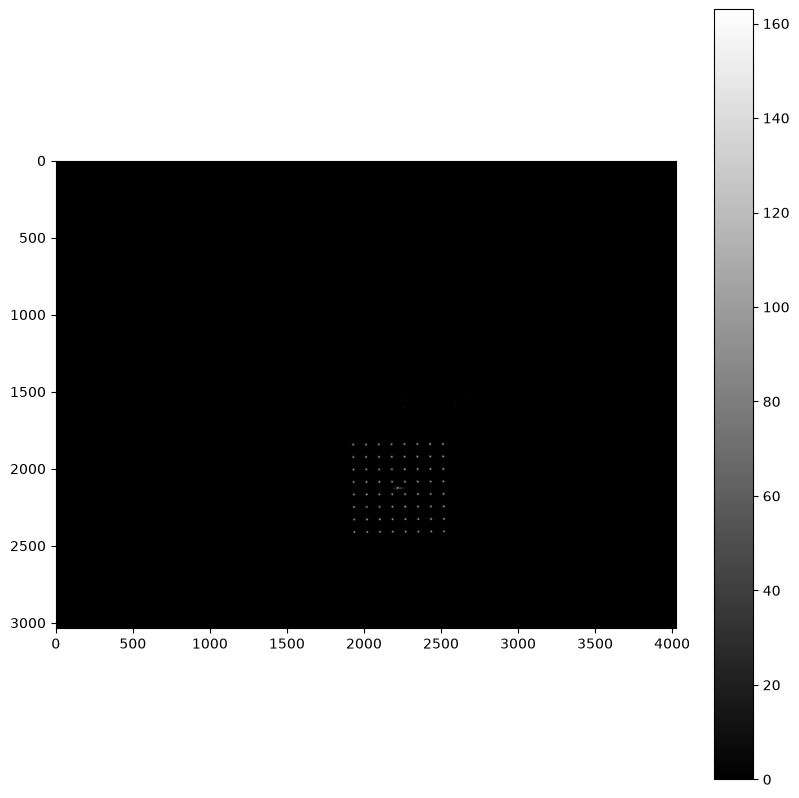

In [10]:
from avt import VimbaCamera

# 你的相机最低曝光约为 22.208 μs
# 先不要使用旧Notebook中的2000，极可能严重过曝
etime = 50

with VimbaCamera() as camera:
    image = camera.capture(etime)

# 你的Mono相机通常直接返回二维灰度图
# 只有确实返回三维图像时才取第一个通道
if image.ndim == 3:
    image = image[:, :, 0]

print("图像尺寸：", image.shape)
print("图像类型：", image.dtype)
print("最大灰度：", image.max())

plt.figure(figsize=(10, 10))
plt.imshow(image, cmap="gray")
plt.colorbar()
plt.show()

## Rotate image

In [ ]:
from scipy.ndimage import binary_dilation
from scipy.ndimage import rotate
print(image.shape)
N,M = image.shape
angle = 0 # 需要旋转的角度 (单位：度, 逆时针方向)
rotated_image_45 = rotate(image, angle=angle, reshape=True)
flipped_image = np.flip(rotated_image_45)
rotated_image = (image.T)[::,::-1]

plt.figure(figsize=(10,10))
plt.imshow(image)
plt.colorbar()
plt.show()

plt.figure(figsize=(10,10))
plt.imshow(rotated_image_45)
plt.colorbar()
plt.show()

print(image.max())

In [ ]:
##%% 5x5: 850:1150,1050:1350
roi_ind = (slice(1100,1900),slice(1800,2600))
plt.imshow(rotated_image_45[*roi_ind])

plt.colorbar()
# print('exposure time:',exposure_time)
print('max:',rotated_image_45[*roi_ind].max())
print('sum:',rotated_image_45[*roi_ind].sum())


In [ ]:
def non_uniformity_show(non_uniformity):
    non_uniformity = np.array(non_uniformity)
    min_index = np.argmin(non_uniformity)
    min_value = np.min(non_uniformity)
    min_index=0
    plt.plot(non_uniformity)
    plt.plot(min_index,min_value,'.')
    plt.annotate(f'Minimum: {min_value:.3f}', xy=(min_index, min_value),
                xytext=(min_index + 1, min_value),
                arrowprops=dict(facecolor='black', arrowstyle='->'))
    plt.title('Tweezer Uniformity Optimization')
    plt.xlabel('Number of iterations')
    plt.ylabel('Non uniformity')
    plt.show()
    

# 适用于4f系统优化
def camera_intensity_array_generate(intensity):
    intensity = np.array(intensity)
    intensity_2d_array = intensity.reshape(9,11)
    intensity_flip = np.transpose(intensity_2d_array)
    intensity_flip = np.flip(intensity_flip, axis=1)
    camera_intensity_array = intensity_flip.flatten()

    return camera_intensity_array

In [ ]:
import plotly.express as px
tmp = rotated_image_45.copy()
print(tmp.shape)
print(tmp)
px.imshow(tmp)

In [ ]:
def get_sorted_top_indices(arr, k=100):
    # 获取最大的k个元素的扁平索引
    flat_indices = np.argpartition(arr.flatten(), -k)[-k:]
    # 转换为二维坐标
    rows, cols = np.unravel_index(flat_indices, arr.shape)
    
    # 按先行后列的自然顺序排序
    sorted_indices = sorted(zip(rows, cols), key=lambda x: (x[0], x[1]))
    
    return sorted_indices

# 获取排序后的索引
sorted_indices = get_sorted_top_indices(rotated_image_45, k=500)

# 打印结果（每行5个索引）
for i, (row, col) in enumerate(sorted_indices, 1):
    print(f"({row:<4}, {col:<4})", end="\t")
    if i % 5 == 0:
        print()  # 每5个换行

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(rotated_image_45)
plt.colorbar()
plt.show()

In [ ]:
from TweezerArrayRegionsExtraction import *
# 850:1150,1050:1350
#roi_ind = (slice(250,650),slice(610,1000))
# 250:520,1270:1540
# 220:850,950:1580
# 坐标为(y,x)1725,2066
points = generate_points([2020-287,1810-298],[2554-273,1818-296],[2012-287,2350-282],[2546-273,2358-282],(5,5))
# points = generate_points([372, 1014],[795,1011], [374,1360],[798,1357],array_size)
# points = generate_points_Tri([266,423],[259,2058], [1876,428],[1872,2063],[43,37])
# points = generate_points_kagome[261,400],[258,2011], [1879,400],[1879,2012],[40,34])
regions = generate_regions(points, [40,40])
# 找到点
aoi = generate_aoi(regions, rotated_image_45, 200)
new_img = rotated_image_45+aoi
plt.figure(figsize=(10,10))
plt.imshow(new_img[1500:2500,1300:2300])


In [ ]:
#regions_trans = np.flip(np.transpose(regions.reshape(8,5,4),axes=(1,0,2)),axis=0).reshape(-1,4)
array_size = [5,5]
lower_than_thres = lambda x: np.max(x) < 10
x1 = regions[:,0]
x2 = regions[:,1]
y1 = regions[:,2]
y2 = regions[:,3]
dark_ls = []
for i in range(array_size[0]*array_size[1]):
    if lower_than_thres(rotated_image_45[x1[i]:x2[i],y1[i]:y2[i]]):
        dark_ls.append(i)
regions_trans = np.delete(regions, dark_ls, axis=0)

# regions_trans = regions_trans[c]#point select order
aoi = generate_aoi(regions_trans, rotated_image_45, 200)
# print(regions_trans)
plt.figure(figsize=(20,20))
plt.imshow(rotated_image_45+aoi)
print(regions_trans)


# print('max:',rotated_image[1103:1128,1063:1088].max())


In [ ]:
regions = regions_trans
##%%
x1 = regions[:,0]
x2 = regions[:,1]
y1 = regions[:,2]
y2 = regions[:,3]

In [ ]:
index = 0
non_uniformity = []
intensity_data = []
targetAmp_data = []
optimize = True
time_interval = 1
rep = 7



In [ ]:
intensity = []
image_ROI = []
for i  in range(len(x1)):
        cur_roi = rotated_image_45[x1[i]:x2[i],y1[i]:y2[i]]
        image_ROI.append(cur_roi)
        print(cur_roi.max())
        # popt, pcov, fitted_image = gaussian_2d_fit(image_ROI[i], show=False)
        # intensity.append(popt[0])
        intensity.append(cur_roi.sum())



intensity = np.array(intensity)
camera_intensity = np.flip(intensity)
# camera_intensity=np.flip(camera_intensity)
intensity_data.append(camera_intensity)
non_uniformity.append(camera_intensity.std()/camera_intensity.mean())
print(camera_intensity.std()/camera_intensity.mean())
non_uniformity_show(non_uniformity)

plt.hist(x = intensity, # 指定绘图数据
         bins = 20, # 指定直方图中条块的个数
         color = 'steelblue', # 指定直方图的填充色
         edgecolor = 'black' # 指定直方图的边框色
         )


In [ ]:
np.save('SLM_img2.npy', SLM_screen)

In [ ]:

while True:

    if optimize:
        tophat_screen_Corrected=IMGpy.SLM_screen_Correct(SLM_screen)
        slm.updateArray(tophat_screen_Corrected)

    time.sleep(time_interval)

    #image = avt.get_image(etime)
    with Vimba() as vimba:
        camera_ids = vimba.camera_ids()
        print(camera_ids[0])
        cam =  vimba.camera(camera_ids[0])
        cam.open()
        cam.arm(mode='SingleFrame')

        # 设置曝光时间
        cam.ExposureTime = etime  # 新版属性直接赋值
        
        # 获取单帧
        frame = cam.acquire_frame()
        image = frame.buffer_data_numpy()

        cam.disarm()
      
    cutted_image = image
# rotated_image = rotate(cutted_image,angle=-4.8,reshape=False) 
    rotated_image_45 = rotate(image, angle=-8.5, reshape=True)
    flipped_image = np.flip(rotated_image_45)
    image_ROI = []
    intensity = []
    print(image_ROI)
    for i  in range(len(x1)):
        cur_roi = rotated_image_45[x1[i]:x2[i],y1[i]:y2[i]]
        image_ROI.append(cur_roi)
        # popt, pcov, fitted_image = gaussian_2d_fit(image_ROI[i], show=False)
        # intensity.append(popt[0])
        intensity.append(image_ROI[i].sum())


    intensity = np.array(intensity)
    # non_uniformity.append(intensity.std()/intensity.mean())
    # camera_intensity = camera_intensity_array_generate(intensity)
    camera_intensity = intensity.copy()
    intensity_data.append(camera_intensity)
    non_uniformity.append(camera_intensity.std()/camera_intensity.mean())
    print(camera_intensity.std()/camera_intensity.mean())
    plt.hist(x = intensity, # 指定绘图数据
         bins = 20, # 指定直方图中条块的个数
         color = 'steelblue', # 指定直方图的填充色
         edgecolor = 'black' # 指定直方图的边框色
         )

    if camera_intensity.std()/camera_intensity.mean()< 0.004 or index == rep:
        break

    index += 1
    if index % 1 ==0:
        print('\n')
        print(index)


    if optimize:
        
        # camera_intensity_array = camera_intensity_array_generate(intensity)
        print(intensity)
        camera_intensity_array = intensity.copy()
        cameraAmp = SLM.camera_Amp_generate(targetAmp, camera_intensity_array) 

        
        targetAmp = SLM.target_adapt(targetAmp, cameraAmp)
        targetAmp_array=targetAmp[np.nonzero(targetAmp)]
        cameraAmp_array=cameraAmp[np.nonzero(cameraAmp)]
        print(targetAmp_array)
        print(cameraAmp_array)
        sum=np.multiply(targetAmp_array,cameraAmp_array)
        print(sum)


        targetAmp_data.append(targetAmp)

        print('Start the new SLM phase generation ...')
        plt.figure()
        plt.hist(x = intensity, # 指定绘图数据
         bins = 20, # 指定直方图中条块的个数
         color = 'steelblue', # 指定直方图的填充色
         edgecolor = 'black' # 指定直方图的边框色
         )

        SLM_Phase = WGS.WGS_phase_generate(torch.from_numpy(SLM.initGaussianAmp), SLM_Phase, torch.from_numpy(targetAmp), Loop=20, threshold=0.01)
        SLM_screen=SLM.phase_to_screen(SLM_Phase.cpu().clone().numpy())
        slm_screen_f_corrected = SLM_screen 
      
        # SLM.target_and_phase_save(targetAmp, SLM_Phase.cpu().clone().numpy(), slm_screen_f_corrected, info = "stagger",
        #                         adapt_times='-sum-'+str(index))
       
plt.figure()
non_uniformity_show(non_uniformity)

plt.figure(figsize=(20,20))
plt.imshow(flipped_image)
plt.colorbar()
plt.show()



In [ ]:
slm.updateArray(tophat_screen_Corrected)

In [ ]:
plt.figure(figsize=(20,20))
plt.imshow(rotated_image_45)
plt.colorbar()
plt.show()

In [ ]:
new_img = rotated_image_45[1733-20:1733+20,1512-20:1512+20]
plt.imshow(new_img)
plt.colorbar()
plt.show()

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def gaussian_2d(xy, amplitude, x0, y0, sigma_x, sigma_y):
    x, y = xy
    g = amplitude * np.exp(
        -(((x - x0) ** 2 / (2 * sigma_x ** 2)) + ((y - y0) ** 2 / (2 * sigma_y ** 2)))
    )
    return g.ravel()

x = np.linspace(0, 39, 40)
y = np.linspace(0, 39, 40)
x, y = np.meshgrid(x, y)

# 将网格数据转换为一维数组
x_data = x.ravel()
y_data = y.ravel()
z_data = new_img.ravel()

# 初始参数猜测
initial_guess = [5, 5, 5, 1, 1]

# 拟合
popt, pcov = curve_fit(gaussian_2d, (x_data, y_data), z_data, p0=initial_guess)

fit_data = gaussian_2d((x_data, y_data), *popt).reshape(x.shape)

# 绘制原始数据和拟合结果
fig = plt.figure(figsize=(12, 6))

# 原始数据
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(x, y, new_img, cmap='viridis', label='Original Data')
ax1.set_title('Original Data')

# 拟合结果
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(x, y, fit_data, cmap='viridis', label='Fitted Data')
ax2.set_title('Fitted Gaussian')

plt.show()

In [ ]:
print("Fitted parameters:")
print(f"Amplitude: {popt[0]}")
print(f"Center (x0, y0): ({popt[1]}, {popt[2]})")
print(f"Sigma (sigma_x, sigma_y): ({popt[3]}, {popt[4]})")

In [ ]:
new_img = rotated_image_45+aoi
plt.figure(figsize=(10,10))
plt.imshow(new_img[1500:2500,1300:2300])

In [ ]:
plt.figure()
plt.hist(x = intensity, # 指定绘图数据
bins = 25, # 指定直方图中条块的个数
color = 'steelblue', # 指定直方图的填充色
edgecolor = 'black', # 指定直方图的边框色
#range = (70000,105000)
)

In [ ]:
blinkslm=BlinkSLM()
blinkslm.write_image((SLM_screen).astype('uint8'))

In [ ]:
print('max:',rotated_image[230:250,1540:1560].max())

In [ ]:
blinkslm.slm_lib.Delete_SDK()


In [ ]:
# SLM.plot_target(targetAmp)
targetAmp_array=np.nonzero(targetAmp)
cameraAmp_array=np.nonzero(cameraAmp)
print(targetAmp.shape)
# print(targetAmp_array)
print(targetAmp[targetAmp_array])
print(cameraAmp[cameraAmp_array])

## slm gen center of array

In [ ]:

singleSLM = SLM_class()

singleSLM.image_init()
center_dis = (20+7*7.5, 0)
# center_dis = (80, 0)
input_shape = (4096, 4096) 
RandomPhase = torch.rand(input_shape, dtype=torch.float32) * 2 * np.pi - np.pi
singleAmp=singleSLM.target_generate(Lattice_type, distance=center_dis, arraysize=(1, 1),  Plot = True)

singleAmp_array=np.nonzero(singleAmp)


single_SLM_Phase=WGS.WGS_phase_generate(torch.tensor(initSLMAmp), torch.tensor(RandomPhase), torch.from_numpy(singleAmp), Loop=20, threshold=0.01, Plot=True)
single_SLM_screen=singleSLM.phase_to_screen(single_SLM_Phase.cpu().clone().numpy())


single_SLM_screen=singleSLM.phase_to_screen(single_SLM_Phase.cpu().clone().numpy())
single_fftAmp,single_fftPhase = singleSLM.phase_to_fftField(single_SLM_Phase.cpu())
plt.figure(figsize=(10,10))       

plt.imshow(single_fftAmp[1000:3000,1000:3000])
plt.show()


## apply center phase to slm

In [ ]:
blinkslm.slm_lib.Delete_SDK()
blinkslm=BlinkSLM()
# slm_phase=SLM.zernike_generate()
blinkslm.write_image((single_SLM_screen).astype('uint8'))

406 -607

In [ ]:

frame = []
# def setup_camera(cam: Camera):
#     with cam:
#         # Try to adjust GeV packet size. This Feature is only available for GigE - Cameras.
#         try:
            
#             cam.exposuretime=etime
#             print(cam.exposuretime)

#         except (AttributeError, VimbaFeatureError):
#             pass
#         try:
#             cam.GVSPAdjustPacketSize.run()

#             while not cam.GVSPAdjustPacketSize.is_done():
#                 pass

#         except (AttributeError, VimbaFeatureError):
#             pass

image = avt.get_image(64)
print(image.shape)

plt.figure(figsize=(20,10))
plt.imshow(image)
plt.colorbar()
plt.show()
print('max:',image.max())

## blink left right

### calculate phase

In [ ]:
center_dis = (20+7*7.5, 0)
upperSLM = SLM_class()

upperSLM.image_init()
upperAmp=upperSLM.target_generate(Lattice_type, distance=(20+7*7.5,50), arraysize=(1, 1),  Plot = True)


upperAmp_array=np.nonzero(upperAmp)


upper_SLM_Phase=WGS.WGS_phase_generate(torch.tensor(initSLMAmp), torch.tensor(RandomPhase), torch.from_numpy(upperAmp), Loop=2, threshold=0.01, Plot=True)
upper_SLM_screen=upperSLM.phase_to_screen(upper_SLM_Phase.cpu().clone().numpy())


upper_SLM_screen=upperSLM.phase_to_screen(upper_SLM_Phase.cpu().clone().numpy())
upper_fftAmp,upper_fftPhase = upperSLM.phase_to_fftField(upper_SLM_Phase.cpu())
plt.figure(figsize=(20,20))
plt.imshow(upper_fftAmp[1000:3000,1000:3000])
plt.show()

lowerSLM = SLM_class()

lowerSLM.image_init()
lowerAmp=lowerSLM.target_generate(Lattice_type, distance=(20+7*7.5, -50), arraysize=(1, 1),  Plot = True)


lowerAmp_array=np.nonzero(lowerAmp)


lower_SLM_Phase=WGS.WGS_phase_generate(torch.tensor(initSLMAmp), torch.tensor(RandomPhase), torch.from_numpy(lowerAmp), Loop=2, threshold=0.01, Plot=True)
lower_SLM_screen=lowerSLM.phase_to_screen(lower_SLM_Phase.cpu().clone().numpy())


lower_SLM_screen=lowerSLM.phase_to_screen(lower_SLM_Phase.cpu().clone().numpy())
lower_fftAmp,lower_fftPhase = lowerSLM.phase_to_fftField(lower_SLM_Phase.cpu())
plt.figure(figsize=(20,20))
plt.imshow(lower_fftAmp[1000:3000,1000:3000])
plt.show()

## apply to slm

In [ ]:
import time
print(upper_SLM_screen)
print(lower_SLM_screen)
while True:
    blinkslm.slm_lib.Delete_SDK()
    blinkslm=BlinkSLM()
    blinkslm.write_image((upper_SLM_screen).astype('uint8'))
    time.sleep(1)
    blinkslm.slm_lib.Delete_SDK()
    blinkslm=BlinkSLM()
    blinkslm.write_image((lower_SLM_screen).astype('uint8'))
    time.sleep(1)

voltex phase

In [ ]:
import time
N, M = (1024,1024)
xx, yy = np.meshgrid(np.arange(-M//2,M//2),np.arange(-N//2,N//2))
phase1 = np.arctan2(yy,xx)
phase1 = ((phase1 + np.pi)/(2*np.pi)*255).astype('uint8')

phase2 = np.arctan2(yy,xx)[::-1,::-1]
phase2 = ((phase1 + np.pi)/(2*np.pi)*255).astype("uint8")

phase = np.copy(phase1)
# phase[512-30:512+31,512-30:512+31] = phase2[512-30:512+31,512-30:512+31]

plt.imshow(phase)
plt.colorbar()
blinkslm.slm_lib.Delete_SDK()
blinkslm=BlinkSLM()
blinkslm.write_image(phase)


In [ ]:
import time
N, M = (1024,1024)
xx, yy = np.meshgrid(np.arange(-M//2,M//2),np.arange(-N//2,N//2))
zero_phase = np.zeros((N,M))

plt.imshow(zero_phase)
plt.colorbar()
blinkslm.slm_lib.Delete_SDK()
blinkslm=BlinkSLM()
blinkslm.write_image(zero_phase)


In [ ]:
blinkslm.slm_lib.Delete_SDK()


In [ ]:
blinkslm=BlinkSLM()
blinkslm.write_image((SLM_screen).astype('uint8'))